**TITLE: Exploratory Data Analysis – Airbnb Cape Town dataset**

**Rachel Atolagbe**

**Date: December 3, 2034**

Data source: https://insideairbnb.com/about/

**ABSTRACT**

This report focuses on cleaning, wrangling, and exploring a Cape Town Airbnb dataset to derive meaningful insights. To resolve problems with data quality, investigate statistical patterns, and spot trends in Airbnb listings, the dataset is processed and examined using Python. The dataset includes key variables such as pricing, availability, host information, and property details, which are analyzed to derive insights into the Airbnb market in Cape Town. The study also formulates three meaningful research questions to investigate relationships and trends within the data, implementing the practical application of data science techniques.

**Import Libaries**

In [1]:
#importing the python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#connecting goole colab to my drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Dataset**

In [3]:
#loading the first file
Airbnb_1 = pd.read_csv('/content/drive/MyDrive/airbnb_1.csv')
Airbnb_1.head() #to print the first five rows

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,availability_60,availability_90,availability_365,calendar_last_scraped,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,3191.0,https://www.airbnb.com/rooms/3191,2.024060e+13,29/06/2024,city scrape,Malleson Garden Cottage,"This is a lovely, separate, self-catering cott...","Mowbray is on the Southern Suburbs line, 6km (...",https://a0.muscache.com/pictures/697022/385407...,3754,...,0,30,305,29/06/2024,NaN,t,1,1,0,0
1,298622.0,https://www.airbnb.com/rooms/298622,2.024060e+13,29/06/2024,city scrape,Stunning Sea View apt on the Cape Peninsula,"This light, airy, well equipped self-catering...","The area is very beautiful, with sea and mount...",https://a0.muscache.com/pictures/3547300/40a29...,1539169,...,34,64,286,29/06/2024,NaN,f,1,1,0,0
2,357793.0,https://www.airbnb.com/rooms/357793,2.024060e+13,30/06/2024,city scrape,CityChic @ the Piazza meets Table Mountain,"Superb 2 bedroom penthouse, with balcony, in t...",NaN,https://a0.muscache.com/pictures/272b7efe-6924...,1802190,...,58,88,143,30/06/2024,NaN,f,1,1,0,0
3,357993.0,https://www.airbnb.com/rooms/357993,2.024060e+13,29/06/2024,city scrape,Beach View Studio with Balcony Walkout,Camps Bay Guesthouse Studio is an ultra-modern...,The studio is situated in the extremely popula...,https://a0.muscache.com/pictures/c222b47a-fab5...,1811942,...,36,66,199,29/06/2024,NaN,f,3,3,0,0
4,15007.0,https://www.airbnb.com/rooms/15007,2.024060e+13,29/06/2024,city scrape,Blaauwberg House (now with inverter),Welcome to our self-catering beach-front famil...,"Bloubergstrand is a lovely, cosy suburb near C...",https://a0.muscache.com/pictures/3b654aa4-248e...,59072,...,51,74,147,29/06/2024,NaN,f,4,4,0,0


In [4]:
#loading the second file
Airbnb_2 = pd.read_csv('/content/drive/MyDrive/airbnb_2.csv')
Airbnb_2.head()

,id,listing_url,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3191.0,https://www.airbnb.com/rooms/3191,79,6,1,31/05/2013,18/06/2024,4.82,4.84,4.70,...,4.96,4.77,4.81,NaN,t,1,1,0,0,0.59
1,298622.0,https://www.airbnb.com/rooms/298622,71,1,0,09/03/2012,17/01/2024,4.94,4.97,4.89,...,4.99,4.87,4.89,NaN,f,1,1,0,0,0.47
2,357793.0,https://www.airbnb.com/rooms/357793,224,16,0,23/07/2012,12/04/2024,4.76,4.87,4.82,...,4.79,4.73,4.83,NaN,f,1,1,0,0,1.54
3,357993.0,https://www.airbnb.com/rooms/357993,108,3,0,23/02/2014,08/02/2024,4.79,4.88,4.89,...,4.84,4.76,4.64,NaN,f,3,3,0,0,0.86
4,15007.0,https://www.airbnb.com/rooms/15007,46,2,0,15/12/2013,02/04/2024,4.83,4.91,4.85,...,4.96,4.93,4.85,NaN,f,4,4,0,0,0.36


In [5]:
#checking the shape of airbnb_1
Airbnb_1.shape

(23564, 62)

In [6]:
#checking the shape of airbnb_2
Airbnb_2.shape

(23564, 21)

In [7]:
#checking the column names of airbnb_2
Airbnb_2.columns

Index(['id', 'listing_url', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'license', 'instant_bookable',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month'],
      dtype='object')

In [8]:
# to merge airbnb_1 and airbnb_2
Airbnb_merged =Airbnb_1.merge(Airbnb_2, on='id')
Airbnb_merged.head()

,id,listing_url_x,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license_y,instant_bookable_y,calculated_host_listings_count_y,calculated_host_listings_count_entire_homes_y,calculated_host_listings_count_private_rooms_y,calculated_host_listings_count_shared_rooms_y,reviews_per_month
0,3191.0,https://www.airbnb.com/rooms/3191,2.024060e+13,29/06/2024,city scrape,Malleson Garden Cottage,"This is a lovely, separate, self-catering cott...","Mowbray is on the Southern Suburbs line, 6km (...",https://a0.muscache.com/pictures/697022/385407...,3754,...,4.96,4.77,4.81,NaN,t,1,1,0,0,0.59
1,298622.0,https://www.airbnb.com/rooms/298622,2.024060e+13,29/06/2024,city scrape,Stunning Sea View apt on the Cape Peninsula,"This light, airy, well equipped self-catering...","The area is very beautiful, with sea and mount...",https://a0.muscache.com/pictures/3547300/40a29...,1539169,...,4.99,4.87,4.89,NaN,f,1,1,0,0,0.47
2,357793.0,https://www.airbnb.com/rooms/357793,2.024060e+13,30/06/2024,city scrape,CityChic @ the Piazza meets Table Mountain,"Superb 2 bedroom penthouse, with balcony, in t...",NaN,https://a0.muscache.com/pictures/272b7efe-6924...,1802190,...,4.79,4.73,4.83,NaN,f,1,1,0,0,1.54
3,357993.0,https://www.airbnb.com/rooms/357993,2.024060e+13,29/06/2024,city scrape,Beach View Studio with Balcony Walkout,Camps Bay Guesthouse Studio is an ultra-modern...,The studio is situated in the extremely popula...,https://a0.muscache.com/pictures/c222b47a-fab5...,1811942,...,4.84,4.76,4.64,NaN,f,3,3,0,0,0.86
4,15007.0,https://www.airbnb.com/rooms/15007,2.024060e+13,29/06/2024,city scrape,Blaauwberg House (now with inverter),Welcome to our self-catering beach-front famil...,"Bloubergstrand is a lovely, cosy suburb near C...",https://a0.muscache.com/pictures/3b654aa4-248e...,59072,...,4.96,4.93,4.85,NaN,f,4,4,0,0,0.36


In [9]:
#checking the shape of the Airbnb_merged dataset
Airbnb_merged.shape

(28732, 82)

In [10]:
#to check the type of data in each column of the airbnb_merged dataset
print(Airbnb_merged.dtypes)

id                                                float64
listing_url_x                                      object
scrape_id                                         float64
last_scraped                                       object
source                                             object
                                                   ...   
calculated_host_listings_count_y                    int64
calculated_host_listings_count_entire_homes_y       int64
calculated_host_listings_count_private_rooms_y      int64
calculated_host_listings_count_shared_rooms_y       int64
reviews_per_month                                 float64
Length: 82, dtype: object


In [11]:
#to find the number of unique values
Airbnb_merged.nunique()



,0
id,22142
listing_url_x,23564
scrape_id,1
last_scraped,2
source,2
...,...
calculated_host_listings_count_y,62
calculated_host_listings_count_entire_homes_y,64
calculated_host_listings_count_private_rooms_y,20
calculated_host_listings_count_shared_rooms_y,6


In [12]:
#providing a summary of the merged dataset
#this information contains the number of columns, column labels, column data types,etc
Airbnb_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28732 entries, 0 to 28731
Data columns (total 82 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              28732 non-null  float64
 1   listing_url_x                                   28732 non-null  object 
 2   scrape_id                                       28732 non-null  float64
 3   last_scraped                                    28732 non-null  object 
 4   source                                          28732 non-null  object 
 5   name                                            28731 non-null  object 
 6   description                                     28274 non-null  object 
 7   neighborhood_overview                           15739 non-null  object 
 8   picture_url                                     28732 non-null  object 
 9   host_id                                

In [13]:
#to check the number of missing values in each column
missing_values = Airbnb_merged.isnull().sum()
print(missing_values)

id                                                   0
listing_url_x                                        0
scrape_id                                            0
last_scraped                                         0
source                                               0
                                                  ... 
calculated_host_listings_count_y                     0
calculated_host_listings_count_entire_homes_y        0
calculated_host_listings_count_private_rooms_y       0
calculated_host_listings_count_shared_rooms_y        0
reviews_per_month                                 7876
Length: 82, dtype: int64


In [14]:
#checking for null values in each column
Airbnb_merged.isnull().any()


,0
id,False
listing_url_x,False
scrape_id,False
last_scraped,False
source,False
...,...
calculated_host_listings_count_y,False
calculated_host_listings_count_entire_homes_y,False
calculated_host_listings_count_private_rooms_y,False
calculated_host_listings_count_shared_rooms_y,False


**Data Cleaning**

In [15]:
#checking the number of null values in each column
Airbnb_merged.isnull().sum(axis=0)

,0
id,0
listing_url_x,0
scrape_id,0
last_scraped,0
source,0
...,...
calculated_host_listings_count_y,0
calculated_host_listings_count_entire_homes_y,0
calculated_host_listings_count_private_rooms_y,0
calculated_host_listings_count_shared_rooms_y,0


In [16]:
# computing the percentage of missing values in each column

total_rows = len(Airbnb_merged)
# missing_values has been calculated earlier

missing_percentage = (missing_values / total_rows) * 100

# Create a DataFrame to display the results
missing_values_percentage = pd.DataFrame({'Column': missing_percentage.index, 'Missing Percentage': missing_percentage.values})

# Display the DataFrame
missing_values_percentage

,Column,Missing Percentage
0,id,0.000000
1,listing_url_x,0.000000
2,scrape_id,0.000000
3,last_scraped,0.000000
4,source,0.000000
...,...,...
77,calculated_host_listings_count_y,0.000000
78,calculated_host_listings_count_entire_homes_y,0.000000
79,calculated_host_listings_count_private_rooms_y,0.000000
80,calculated_host_listings_count_shared_rooms_y,0.000000


In [17]:
# Dropping columns with more than 40% missing values
Airbnb_cleaned = Airbnb_merged.dropna(thresh=len(Airbnb_merged)*0.6, axis=1)

# Display the cleaned DataFrame
Airbnb_cleaned.head()

,id,listing_url_x,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable_y,calculated_host_listings_count_y,calculated_host_listings_count_entire_homes_y,calculated_host_listings_count_private_rooms_y,calculated_host_listings_count_shared_rooms_y,reviews_per_month
0,3191.0,https://www.airbnb.com/rooms/3191,2.024060e+13,29/06/2024,city scrape,Malleson Garden Cottage,"This is a lovely, separate, self-catering cott...",https://a0.muscache.com/pictures/697022/385407...,3754,https://www.airbnb.com/users/show/3754,...,4.97,4.96,4.77,4.81,t,1,1,0,0,0.59
1,298622.0,https://www.airbnb.com/rooms/298622,2.024060e+13,29/06/2024,city scrape,Stunning Sea View apt on the Cape Peninsula,"This light, airy, well equipped self-catering...",https://a0.muscache.com/pictures/3547300/40a29...,1539169,https://www.airbnb.com/users/show/1539169,...,4.97,4.99,4.87,4.89,f,1,1,0,0,0.47
2,357793.0,https://www.airbnb.com/rooms/357793,2.024060e+13,30/06/2024,city scrape,CityChic @ the Piazza meets Table Mountain,"Superb 2 bedroom penthouse, with balcony, in t...",https://a0.muscache.com/pictures/272b7efe-6924...,1802190,https://www.airbnb.com/users/show/1802190,...,4.78,4.79,4.73,4.83,f,1,1,0,0,1.54
3,357993.0,https://www.airbnb.com/rooms/357993,2.024060e+13,29/06/2024,city scrape,Beach View Studio with Balcony Walkout,Camps Bay Guesthouse Studio is an ultra-modern...,https://a0.muscache.com/pictures/c222b47a-fab5...,1811942,https://www.airbnb.com/users/show/1811942,...,4.93,4.84,4.76,4.64,f,3,3,0,0,0.86
4,15007.0,https://www.airbnb.com/rooms/15007,2.024060e+13,29/06/2024,city scrape,Blaauwberg House (now with inverter),Welcome to our self-catering beach-front famil...,https://a0.muscache.com/pictures/3b654aa4-248e...,59072,https://www.airbnb.com/users/show/59072,...,4.98,4.96,4.93,4.85,f,4,4,0,0,0.36


In [18]:
# checking the shape of the new datadrame to determine the number of remaing columns
Airbnb_cleaned.shape

(28732, 74)

In [19]:
Airbnb_cleaned.columns

Index(['id', 'listing_url_x', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'picture_url', 'host_id', 'host_url', 'host_name',
       'host_since', 'host_location', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms',
       'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'calendar_last

In [20]:
# selecting variables of intrest
New_Airbnb = Airbnb_cleaned[['id', 'name','source', 'description', 'host_id', 'host_url','host_name', 'property_type', 'room_type', 'accommodates', 'amenities','bedrooms', 'price', 'minimum_nights', 'maximum_nights', 'availability_365','instant_bookable_x', 'number_of_reviews', 'review_scores_rating', 'calculated_host_listings_count_entire_homes_y', 'calculated_host_listings_count_private_rooms_y', 'calculated_host_listings_count_shared_rooms_y','latitude', 'longitude']]
New_Airbnb.head()


,id,name,source,description,host_id,host_url,host_name,property_type,room_type,accommodates,...,maximum_nights,availability_365,instant_bookable_x,number_of_reviews,review_scores_rating,calculated_host_listings_count_entire_homes_y,calculated_host_listings_count_private_rooms_y,calculated_host_listings_count_shared_rooms_y,latitude,longitude
0,3191.0,Malleson Garden Cottage,city scrape,"This is a lovely, separate, self-catering cott...",3754,https://www.airbnb.com/users/show/3754,Brigitte,Entire home,Entire home/apt,2,...,730,305,t,79,4.82,1,0,0,-33.94762,18.47599
1,298622.0,Stunning Sea View apt on the Cape Peninsula,city scrape,"This light, airy, well equipped self-catering...",1539169,https://www.airbnb.com/users/show/1539169,Diane,Entire rental unit,Entire home/apt,4,...,180,286,f,71,4.94,1,0,0,-34.20875,18.45940
2,357793.0,CityChic @ the Piazza meets Table Mountain,city scrape,"Superb 2 bedroom penthouse, with balcony, in t...",1802190,https://www.airbnb.com/users/show/1802190,Liliane,Entire rental unit,Entire home/apt,4,...,90,143,f,224,4.76,1,0,0,-33.92528,18.42022
3,357993.0,Beach View Studio with Balcony Walkout,city scrape,Camps Bay Guesthouse Studio is an ultra-modern...,1811942,https://www.airbnb.com/users/show/1811942,Shannon,Entire guest suite,Entire home/apt,2,...,90,199,f,108,4.79,3,0,0,-33.96455,18.38113
4,15007.0,Blaauwberg House (now with inverter),city scrape,Welcome to our self-catering beach-front famil...,59072,https://www.airbnb.com/users/show/59072,Dirk,Entire home,Entire home/apt,6,...,120,147,f,46,4.83,4,0,0,-33.80001,18.46063


In [21]:
# checking if all intrested variables are present in the Airbnb_cleaned dataset
incorrect_columns = list(set(New_Airbnb) - set(Airbnb_cleaned.columns))

if incorrect_columns:
    print("Incorrect column names:", incorrect_columns)
else:
    print("All columns in 'New_Airbnb' are present in the DataFrame.")

All columns in 'New_Airbnb' are present in the DataFrame.


In [22]:
# checking the shape of the new dataset
New_Airbnb.shape

(28732, 24)

In [23]:
New_Airbnb.isnull().any()

,0
id,False
name,True
source,False
description,True
host_id,False
host_url,False
host_name,False
property_type,False
room_type,False
accommodates,False


In [24]:
# Dropping the NULL rows
Cleaned_Airbnb = New_Airbnb.dropna()
Cleaned_Airbnb.shape   #checking the shape of the data set after dropping null rows


(18370, 24)

In [25]:
#Check if all NULLS are gone
Cleaned_Airbnb.isnull().any()

,0
id,False
name,False
source,False
description,False
host_id,False
host_url,False
host_name,False
property_type,False
room_type,False
accommodates,False


In [26]:
#How many rows with NULL values were removed?
rows_before_cleaning = len(New_Airbnb)
rows_after_cleaning = len(Cleaned_Airbnb)
rows_removed = rows_before_cleaning - rows_after_cleaning

print(rows_removed)

10362


In [27]:
# checking for duplicate rows
duplicate_rows = Cleaned_Airbnb.duplicated()
duplicate_rows.sum()

np.int64(137)

In [28]:
# dropping the duplicate rows
Cleaned_Airbnb_2 = Cleaned_Airbnb.drop_duplicates()
Cleaned_Airbnb_2.shape

(18233, 24)

In [29]:
# To calculate the number of rows before removing duplicates
rows_before_duplicate_removal = len(Cleaned_Airbnb)

# To calculate the number of rows after removing duplicates
rows_after_duplicate_removal = len(Cleaned_Airbnb_2)

# Calculate the number of duplicate rows removed
duplicate_rows_removed = rows_before_duplicate_removal - rows_after_duplicate_removal

print(f"Number of duplicate rows removed: {duplicate_rows_removed}")

Number of duplicate rows removed: 137


In [30]:
Cleaned_Airbnb_2.head()

,id,name,source,description,host_id,host_url,host_name,property_type,room_type,accommodates,...,maximum_nights,availability_365,instant_bookable_x,number_of_reviews,review_scores_rating,calculated_host_listings_count_entire_homes_y,calculated_host_listings_count_private_rooms_y,calculated_host_listings_count_shared_rooms_y,latitude,longitude
0,3191.0,Malleson Garden Cottage,city scrape,"This is a lovely, separate, self-catering cott...",3754,https://www.airbnb.com/users/show/3754,Brigitte,Entire home,Entire home/apt,2,...,730,305,t,79,4.82,1,0,0,-33.94762,18.47599
1,298622.0,Stunning Sea View apt on the Cape Peninsula,city scrape,"This light, airy, well equipped self-catering...",1539169,https://www.airbnb.com/users/show/1539169,Diane,Entire rental unit,Entire home/apt,4,...,180,286,f,71,4.94,1,0,0,-34.20875,18.45940
2,357793.0,CityChic @ the Piazza meets Table Mountain,city scrape,"Superb 2 bedroom penthouse, with balcony, in t...",1802190,https://www.airbnb.com/users/show/1802190,Liliane,Entire rental unit,Entire home/apt,4,...,90,143,f,224,4.76,1,0,0,-33.92528,18.42022
3,357993.0,Beach View Studio with Balcony Walkout,city scrape,Camps Bay Guesthouse Studio is an ultra-modern...,1811942,https://www.airbnb.com/users/show/1811942,Shannon,Entire guest suite,Entire home/apt,2,...,90,199,f,108,4.79,3,0,0,-33.96455,18.38113
4,15007.0,Blaauwberg House (now with inverter),city scrape,Welcome to our self-catering beach-front famil...,59072,https://www.airbnb.com/users/show/59072,Dirk,Entire home,Entire home/apt,6,...,120,147,f,46,4.83,4,0,0,-33.80001,18.46063


In [31]:
# checking the data type of each column
Cleaned_Airbnb_2.dtypes

,0
id,float64
name,object
source,object
description,object
host_id,int64
host_url,object
host_name,object
property_type,object
room_type,object
accommodates,int64


In [32]:
# Converting the 'id' column from float to integer
Cleaned_Airbnb_2['id'] = Cleaned_Airbnb_2['id'].astype(int)

# Confirm the change
print(Cleaned_Airbnb_2['id'].dtype)

int64


/tmp/ipython-input-2783156709.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Cleaned_Airbnb_2['id'] = Cleaned_Airbnb_2['id'].astype(int)


In [33]:
#to change the 'price' data type to float
Cleaned_Airbnb_2['price'] = Cleaned_Airbnb_2['price'].replace('[\$,]', '', regex=True).astype(float)

# Confirm the change
print(Cleaned_Airbnb_2['price'].dtype)

float64


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-759598874.py:2: SyntaxWarning: invalid escape sequence '\$'
  Cleaned_Airbnb_2['price'] = Cleaned_Airbnb_2['price'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipython-input-759598874.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Cleaned_Airbnb_2['price'] = Cleaned_Airbnb_2['price'].replace('[\$,]', '', regex=True).astype(float)


In [34]:
# to summarize the dataset
Cleaned_Airbnb_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18233 entries, 0 to 28713
Data columns (total 24 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              18233 non-null  int64  
 1   name                                            18233 non-null  object 
 2   source                                          18233 non-null  object 
 3   description                                     18233 non-null  object 
 4   host_id                                         18233 non-null  int64  
 5   host_url                                        18233 non-null  object 
 6   host_name                                       18233 non-null  object 
 7   property_type                                   18233 non-null  object 
 8   room_type                                       18233 non-null  object 
 9   accommodates                                

In [35]:
print(Cleaned_Airbnb_2['amenities'].head())

0    ["Coffee maker", "Iron", "Cooking basics", "Sh...
1    ["Pack \u2019n play/Travel crib", "Iron", "Coo...
2    ["Coffee maker", "Iron", "Room-darkening shade...
3    ["Coffee maker", "Iron", "Cooking basics", "Sh...
4    ["Pets allowed", "Free parking garage on premi...
Name: amenities, dtype: object


In [36]:
# to count the number of ammenities for each listing
Cleaned_Airbnb_2['number_of_amenities'] = Cleaned_Airbnb_2['amenities'].apply(len)


/tmp/ipython-input-2909446730.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Cleaned_Airbnb_2['number_of_amenities'] = Cleaned_Airbnb_2['amenities'].apply(len)


In [37]:
print(Cleaned_Airbnb_2[['amenities', 'number_of_amenities']].head())

                                           amenities  number_of_amenities
0  ["Coffee maker", "Iron", "Cooking basics", "Sh...                  583
1  ["Pack \u2019n play/Travel crib", "Iron", "Coo...                 1448
2  ["Coffee maker", "Iron", "Room-darkening shade...                  940
3  ["Coffee maker", "Iron", "Cooking basics", "Sh...                  460
4  ["Pets allowed", "Free parking garage on premi...                 1351


**Exploratory Data Analysis (EDA)**

In [38]:
Cleaned_Airbnb_2.describe()

,id,host_id,accommodates,bedrooms,price,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,calculated_host_listings_count_entire_homes_y,calculated_host_listings_count_private_rooms_y,calculated_host_listings_count_shared_rooms_y,latitude,longitude,number_of_amenities
count,1.823300e+04,1.823300e+04,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000,18233.000000
mean,4.901425e+17,1.915728e+08,3.665003,1.771678,2331.902210,3.479899,496.123128,227.634838,29.371031,4.782956,14.101245,0.767400,0.012944,-33.955880,18.461106,699.981407
std,4.713740e+17,1.881912e+08,2.313488,1.380506,11038.160694,10.445897,447.520114,107.976219,49.008856,3.512925,27.380112,2.554373,0.219065,0.097099,0.114988,369.905982
min,3.191000e+03,3.754000e+03,1.000000,0.000000,180.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-34.262840,18.320200,2.000000
25%,2.975743e+07,3.096042e+07,2.000000,1.000000,773.000000,2.000000,90.000000,147.000000,4.000000,4.680000,1.000000,0.000000,0.000000,-34.011050,18.395650,417.000000
50%,6.231670e+17,1.065843e+08,3.000000,1.000000,1200.000000,2.000000,365.000000,249.000000,11.000000,4.880000,2.000000,0.000000,0.000000,-33.926730,18.422191,665.000000
75%,9.910930e+17,3.591360e+08,4.000000,2.000000,2200.000000,3.000000,1125.000000,328.000000,33.000000,5.000000,10.000000,0.000000,0.000000,-33.911050,18.474060,951.000000
max,1.187750e+18,5.830601e+08,16.000000,50.000000,999538.000000,730.000000,3000.000000,365.000000,756.000000,466.000000,134.000000,39.000000,6.000000,-33.577100,18.936030,2263.000000


In [39]:
# Descriptive statistics for 'price'
Cleaned_Airbnb_2['price'].describe()

,price
count,18233.000000
mean,2331.902210
std,11038.160694
min,180.000000
25%,773.000000
50%,1200.000000
75%,2200.000000
max,999538.000000


In [40]:
Cleaned_Airbnb_2['price'].head()

,price
0,635.0
1,1500.0
2,2000.0
3,1700.0
4,3102.0


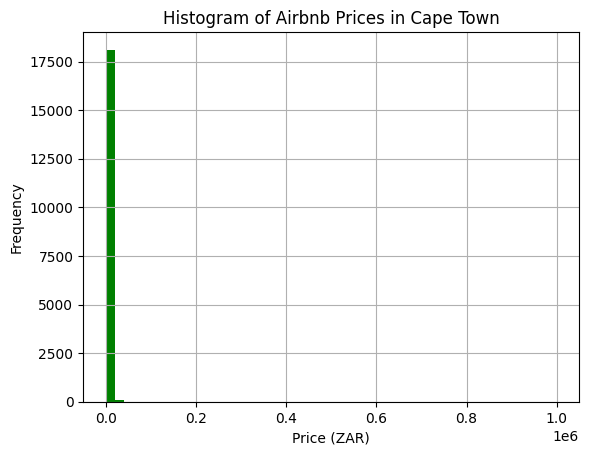

In [41]:
# to plot a histogram of prices of the airbnbs
plt.hist(Cleaned_Airbnb_2['price'], bins=50, density=False, facecolor='green')

plt.xlabel('Price (ZAR)')
plt.ylabel('Frequency')
plt.title('Histogram of Airbnb Prices in Cape Town')

plt.grid(True)
# to display the histogram
plt.show()

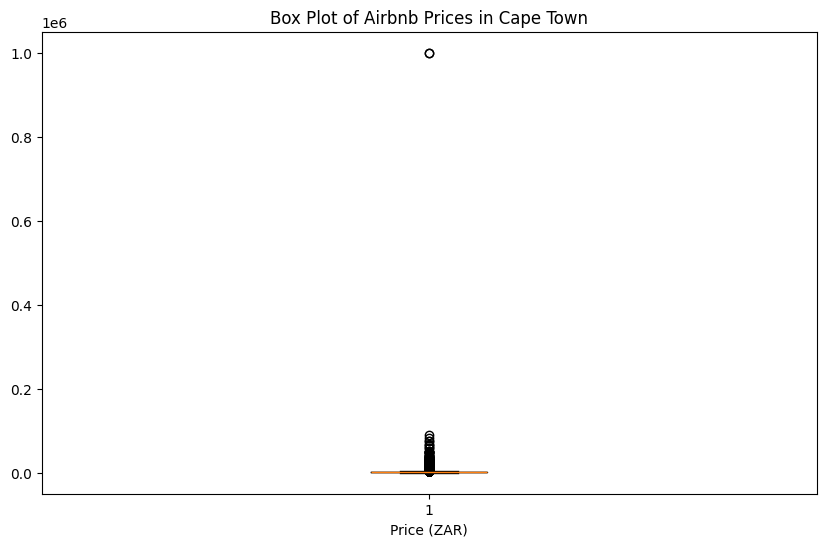

In [42]:
# Creating a box plot for the price column
plt.figure(figsize=(10, 6))
plt.boxplot(Cleaned_Airbnb_2['price'])

plt.title('Box Plot of Airbnb Prices in Cape Town')
plt.xlabel('Price (ZAR)')
plt.show()

In [43]:
# to calculate quantiles and IQR
Q1 = Cleaned_Airbnb_2['price'].quantile(0.25)
Q3 = Cleaned_Airbnb_2['price'].quantile(0.75)
IQR = Q3 - Q1

# Defining upper and lower bounds for outlier detection
lower_bound_price = Q1 - 1.5 * IQR
upper_bound_price = Q3 + 1.5 * IQR

# to identify outliers
outliers = Cleaned_Airbnb_2[(Cleaned_Airbnb_2['price'] < lower_bound_price) | (Cleaned_Airbnb_2['price'] > upper_bound_price)]
outliers.head()


,id,name,source,description,host_id,host_url,host_name,property_type,room_type,accommodates,...,availability_365,instant_bookable_x,number_of_reviews,review_scores_rating,calculated_host_listings_count_entire_homes_y,calculated_host_listings_count_private_rooms_y,calculated_host_listings_count_shared_rooms_y,latitude,longitude,number_of_amenities
13,400107,Camps Bay Villa with Mountain Views near the B...,city scrape,Best location in Camps Bay! Compact home with...,1997313,https://www.airbnb.com/users/show/1997313,Shirley,Entire villa,Entire home/apt,8,...,253,f,55,4.98,4,2,0,-33.95426,18.37938,982
18,15704,Hollywood Mansion & Spa Camps Bay with Butler,city scrape,5 Star Luxury Villa WINNER! Best Self Catering...,61441,https://www.airbnb.com/users/show/61441,Kevin,Entire villa,Entire home/apt,12,...,258,f,2,5.00,5,0,0,-33.96590,18.37724,582
26,474596,5 bedroom holiday home to rent in Cape Town,city scrape,Tastefully decorated home offering 5 en-suite ...,2352753,https://www.airbnb.com/users/show/2352753,Cindy,Entire home,Entire home/apt,10,...,342,f,3,5.00,1,0,0,-33.96919,18.48820,357
33,20263,Villa Honeywood Residence 5 star Service,city scrape,This luxury 5 star rated Villa will be rented ...,837661,https://www.airbnb.com/users/show/837661,Daniel,Entire villa,Entire home/apt,6,...,269,f,2,5.00,2,0,0,-34.13647,18.41994,1395
52,96036,Unique Town House -Green Point,city scrape,Peace & Quiet in a great location with all the...,510489,https://www.airbnb.com/users/show/510489,Christan,Entire home,Entire home/apt,4,...,364,f,25,4.84,1,0,0,-33.91017,18.41032,976


In [44]:
# to count the number of outliers
num_outliers = len(outliers)
print(num_outliers)

2005


In [45]:
#to remove outliers
Cleaned_Airbnb_2 = Cleaned_Airbnb_2[
    (Cleaned_Airbnb_2['price'] >= lower_bound_price) &
    (Cleaned_Airbnb_2['price'] <= upper_bound_price)
]

In [46]:
# Descriptive statistics for 'review_scores_rating'
Cleaned_Airbnb_2['review_scores_rating'].describe()

,review_scores_rating
count,16228.000000
mean,4.777133
std,3.721600
min,1.000000
25%,4.670000
50%,4.870000
75%,5.000000
max,466.000000


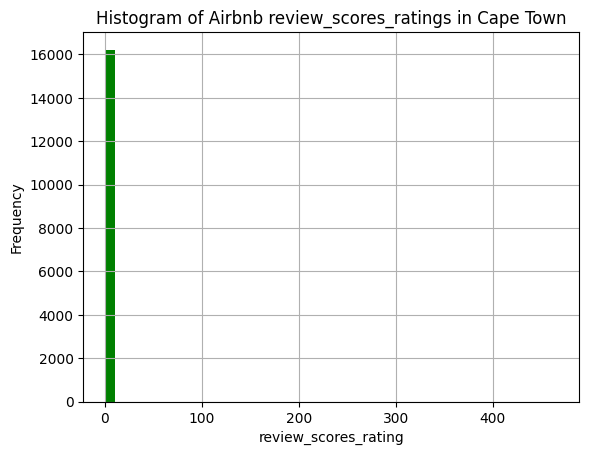

In [47]:
# to plot a histogram of review_scores_rating of the airbnbs
plt.hist(Cleaned_Airbnb_2['review_scores_rating'], bins=50, density=False, facecolor='green')

plt.xlabel('review_scores_rating')
plt.ylabel('Frequency')
plt.title('Histogram of Airbnb review_scores_ratings in Cape Town')

plt.grid(True)
# to display the histogram
plt.show()

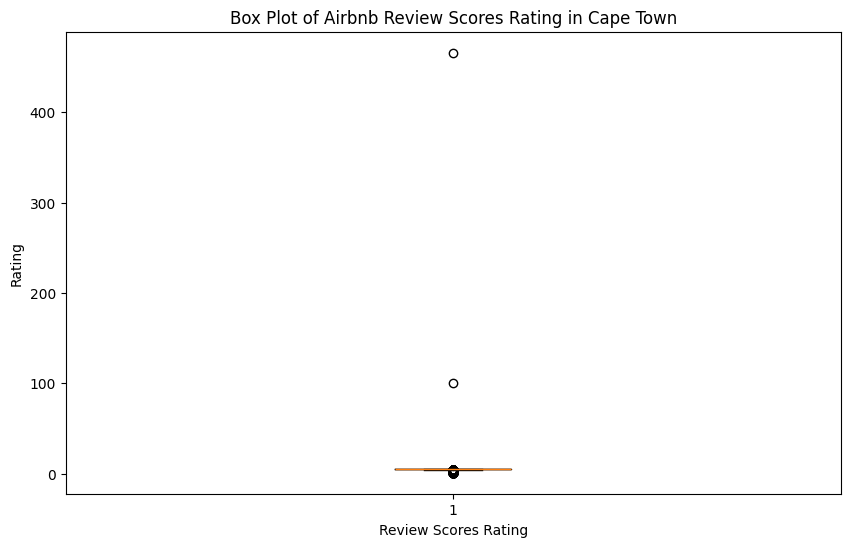

In [48]:
# Creating a box plot for the review_scores_rating column
plt.figure(figsize=(10, 6))
plt.boxplot(Cleaned_Airbnb_2['review_scores_rating'])

plt.title('Box Plot of Airbnb Review Scores Rating in Cape Town')
plt.xlabel('Review Scores Rating')
plt.ylabel('Rating')
plt.show()

In [49]:
# to calculate quantiles and IQR
Q1_rating = Cleaned_Airbnb_2['review_scores_rating'].quantile(0.25)
Q3_rating = Cleaned_Airbnb_2['review_scores_rating'].quantile(0.75)
IQR_rating = Q3_rating - Q1_rating

# Defining upper and lower bounds for outlier detection
lower_bound_rating = Q1_rating - 1.5 * IQR_rating
upper_bound_rating = Q3_rating + 1.5 * IQR_rating

# Identify outliers
outliers_rating = Cleaned_Airbnb_2[(Cleaned_Airbnb_2['review_scores_rating'] < lower_bound_rating) | (Cleaned_Airbnb_2['review_scores_rating'] > upper_bound_rating)]

# Display the outliers
outliers_rating.head()

,id,name,source,description,host_id,host_url,host_name,property_type,room_type,accommodates,...,availability_365,instant_bookable_x,number_of_reviews,review_scores_rating,calculated_host_listings_count_entire_homes_y,calculated_host_listings_count_private_rooms_y,calculated_host_listings_count_shared_rooms_y,latitude,longitude,number_of_amenities
32,511414,"312 Rockwell - Sunny + Modern with Balcony, Ai...",city scrape,Welcome to this modern luxury apartment. A ful...,2516345,https://www.airbnb.com/users/show/2516345,Jaco,Entire rental unit,Entire home/apt,2,...,328,t,4,3.50,80,0,0,-33.91577,18.41777,552
37,518545,"CBD Loft Free Wi-Fi, Parking, Gym, Balcony and...",city scrape,"This bright open plan kitchen, lounge with its...",2516345,https://www.airbnb.com/users/show/2516345,Jaco,Entire rental unit,Entire home/apt,4,...,260,t,6,3.83,80,0,0,-33.92218,18.42151,284
41,36347,"Cosy, Downtown Loft with Mountain Views over R...",city scrape,Our cozy little loft features an architect-des...,156196,https://www.airbnb.com/users/show/156196,Alan,Entire loft,Entire home/apt,2,...,116,f,281,100.00,1,0,0,-33.92456,18.42238,865
49,590826,Cape Town Waterfront Apartment,city scrape,Beautiful air-conditioned vacation apartment w...,2915241,https://www.airbnb.com/users/show/2915241,Nicole,Entire serviced apartment,Entire home/apt,3,...,362,f,9,4.00,3,1,0,-33.91248,18.42548,795
60,636290,"Colourful Loft with Free Wi-fi, Parking and gym",city scrape,14 Harbour Terraces is a 1 bedroom loft apartm...,2516345,https://www.airbnb.com/users/show/2516345,Jaco,Entire rental unit,Entire home/apt,2,...,363,t,8,3.88,80,0,0,-33.91129,18.41617,482


In [50]:
num_outliers_rating = len(outliers_rating)
print(f"Number of outliers in review_scores_rating: {num_outliers_rating}")

Number of outliers in review_scores_rating: 1060


In [51]:
Cleaned_Airbnb_2 = Cleaned_Airbnb_2[
    (Cleaned_Airbnb_2['review_scores_rating'] >= lower_bound_rating) &
    (Cleaned_Airbnb_2['review_scores_rating'] <= upper_bound_rating)
]

In [52]:
Cleaned_Airbnb_2['availability_365'].describe()

,availability_365
count,15168.000000
mean,228.195939
std,107.424566
min,0.000000
25%,148.000000
50%,249.000000
75%,328.000000
max,365.000000


In [53]:
Cleaned_Airbnb_2['number_of_reviews'].describe()

,number_of_reviews
count,15168.000000
mean,32.689939
std,51.701472
min,1.000000
25%,4.000000
50%,13.000000
75%,38.000000
max,756.000000


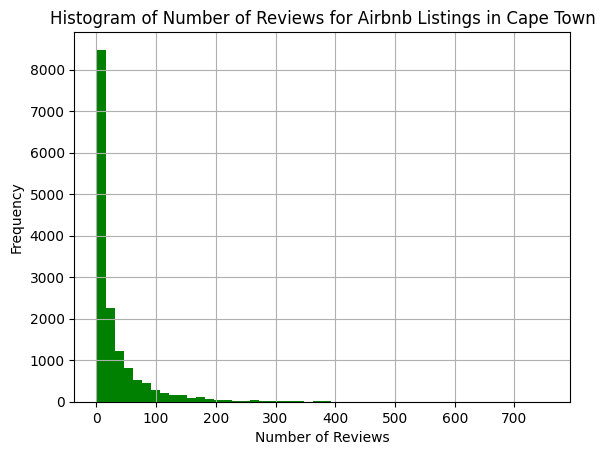

In [54]:
# Plotting the histogram
plt.hist(Cleaned_Airbnb_2['number_of_reviews'], bins=50, density=False, facecolor='green')

plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Reviews for Airbnb Listings in Cape Town')
plt.grid(True)
plt.show()

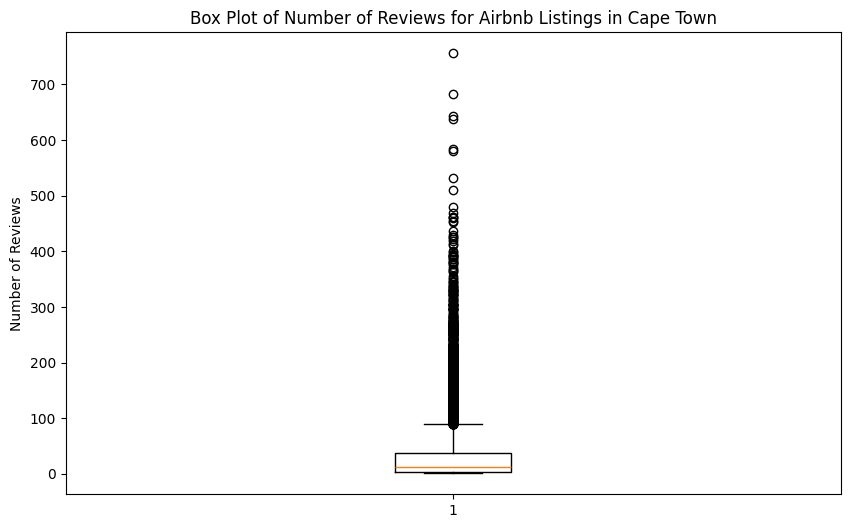

In [55]:
# Creating the box plot
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.boxplot(Cleaned_Airbnb_2['number_of_reviews'])

plt.title('Box Plot of Number of Reviews for Airbnb Listings in Cape Town')
plt.ylabel('Number of Reviews')
plt.show()

In [56]:
# Calculate quantiles and IQR
Q1 = np.percentile(Cleaned_Airbnb_2['number_of_reviews'], 25)
Q3 = np.percentile(Cleaned_Airbnb_2['number_of_reviews'], 75)
IQR = Q3 - Q1

# Define upper and lower bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = Cleaned_Airbnb_2[(Cleaned_Airbnb_2['number_of_reviews'] < lower_bound) | (Cleaned_Airbnb_2['number_of_reviews'] > upper_bound)]

# Count the number of outliers
num_outliers = len(outliers)
print(f"Number of outliers in 'number_of_reviews': {num_outliers}")

Number of outliers in 'number_of_reviews': 1460


In [57]:
# Assuming you have already calculated 'lower_bound' and 'upper_bound' as in the previous code

# Remove outliers
Cleaned_Airbnb_2 = Cleaned_Airbnb_2[
    (Cleaned_Airbnb_2['number_of_reviews'] >= lower_bound) &
    (Cleaned_Airbnb_2['number_of_reviews'] <= upper_bound)
]

# Verify the removal
print(f"Shape of dataframe after removing outliers: {Cleaned_Airbnb_2.shape}")

Shape of dataframe after removing outliers: (13708, 25)


In [58]:
variables= ['review_scores_rating', 'number_of_amenities', 'availability_365', 'number_of_reviews', 'price', 'latitude', 'longitude' ]

In [59]:
# the dataset cleaned_Airbnb_2 is now named df
df= Cleaned_Airbnb_2
# to check how the features are correlated with the review scores rating
for f in variables:
    related = df['review_scores_rating'].corr(df[f])
    print("%s: %f" % (f,related)) # %s (string) and %f (float) are placeholders for feature name and corr coefficient.

review_scores_rating: 1.000000
number_of_amenities: 0.136902
availability_365: -0.051831
number_of_reviews: -0.118664
price: 0.111296
latitude: -0.087386
longitude: 0.061710


**Correlation**

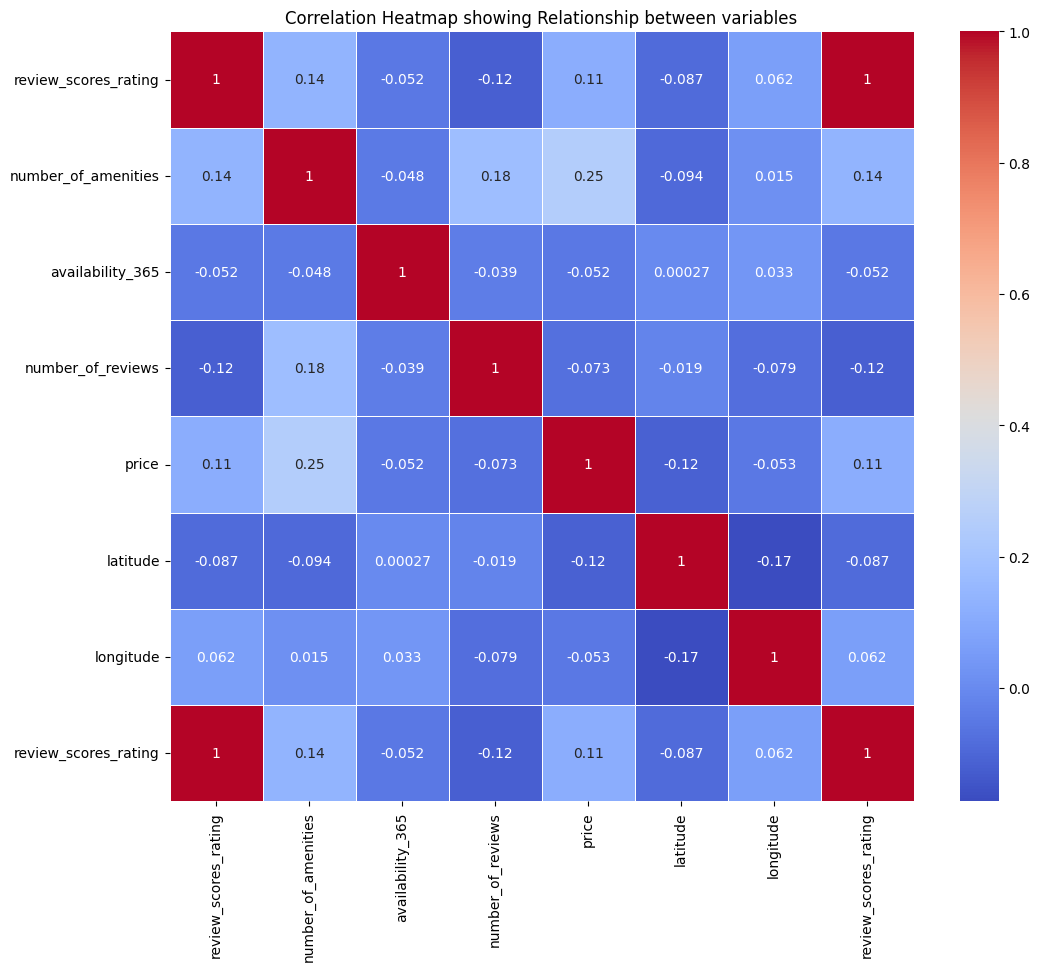

In [60]:
# Create a subset DataFrame with variables
subset_df = df[variables + ['review_scores_rating']]

# Compute the correlation matrix
correlation_matrix = subset_df.corr()

# Create a heatmap using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap showing Relationship between variables')
plt.show()



**Discussion on Relationship between variables**

The heatmap shows the following relationships between variables:

* **Price and Number of Amenities:** has a  moderate positive correlation of 0.25. The correlation shows that listings with more amenities are likely  to have higher prices which means additional facilities may be a reason for high price.

* **Review Scores Rating and Number of Amenities:** has a weak positive correlation of 0.14. That is listings with more amenities might receive slightly better ratings.

* **Price and Review Scores Rating:** has a weak positive correlation of 0.11. Higher prices may be associated with slightly better ratings, but the relationship is not strong. The absence of a strong correlation implies that other factors, such as location, room type, or amenities, may play a more important role in determining price than review scores.

* **Number of Reviews and Review Scores Rating**: has a weak negative correlation of -0.12. Listings with more reviews tend to have slightly lower ratings, possibly resulting from large exposure to various individual opinions.

* **Latitude/Longitude with Price and Review Scores Rating**: Negligible correlations. Location in terms of latitude and longitude does not strongly influence price or ratings.

Overall, the relationships are mostly weak, with the strongest being between price and number of amenities.

**Conclusion**

This project provided an in-depth exploration of Airbnb listings in Cape Town using Python for data cleaning, wrangling, and exploratory data analysis. After removing missing values and extreme outliers, the dataset offered a clearer picture of the city’s short-term rental market.  

The findings showed that most listings fall within moderate price ranges, with generally high guest satisfaction across hosts and properties. While amenities and property type influenced pricing slightly, location appeared to play a smaller role. Overall, the analysis highlights key market patterns and provides a strong foundation for further work such as predictive modeling or location-based pricing optimization.
